# Astrophysical Objects Image Classification 

In [1]:

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Rescaling
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import PIL
from pathlib import Path
import shutil

2025-10-26 18:04:11.433227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761501851.664201      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761501851.728423      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Step 1: Clean the Dataset (Remove Corrupted Images)

In [2]:
def validate_and_clean_dataset(source_dir, dest_dir):
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    corrupted_count = 0
    valid_count = 0
    Path(dest_dir).mkdir(parents=True, exist_ok=True)
    for class_folder in Path(source_dir).iterdir():
        if not class_folder.is_dir():
            continue
        dest_class_folder = Path(dest_dir) / class_folder.name
        dest_class_folder.mkdir(parents=True, exist_ok=True)
        
        print(f"Processing class: {class_folder.name}")
        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() not in valid_extensions:
                continue
                
            try:
                img = PIL.Image.open(img_file)
                img.verify()
                img = PIL.Image.open(img_file)
                img = img.convert('RGB')  
                dest_file = dest_class_folder / img_file.name
                img.save(dest_file, 'JPEG')
                valid_count += 1
                
            except Exception as e:
                print(f"   Corrupted: {img_file.name} - {str(e)[:50]}")
                corrupted_count += 1
    
   
    print(f" Valid images: {valid_count}")
    print(f" Corrupted images: {corrupted_count}")
 
    
    return valid_count, corrupted_count

In [3]:

source_directory = "/kaggle/input/astrophysical-objects-image-dataset/astro_dataset_maxia/astro_dataset_maxia/training"
clean_directory = "/kaggle/working/clean_training_data"

print("Cleaning dataset...")
valid, corrupted = validate_and_clean_dataset(source_directory, clean_directory)

Cleaning dataset...
Processing class: jupiter
Processing class: uranus
Processing class: pluto
Processing class: earth
Processing class: galaxy
Processing class: mars
Processing class: asteroid
Processing class: venus
Processing class: saturn
Processing class: black_hole
Processing class: neptune
Processing class: mercury
 Valid images: 2416
 Corrupted images: 0


## Step 2: Load Clean Dataset

In [4]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    clean_directory,
    image_size=(224, 224),
    batch_size=32,
    label_mode='int',
    shuffle=True,
    seed=42
)

Found 2416 files belonging to 12 classes.


2025-10-26 18:05:42.787051: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:

class_names = train_dataset.class_names
print(f"classes: {class_names}")
print(f"no of classes: {len(class_names)}")

classes: ['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']
no of classes: 12


In [6]:

for x, y in train_dataset.take(1):
    print("\nData shapes:")
    print(f"X shape: {x.shape}")
    print(f"Y shape: {y.shape}")
    print(f"X value range: [{x.numpy().min():.2f}, {x.numpy().max():.2f}]")
    print(f"Y sample: {y.numpy()}")


Data shapes:
X shape: (32, 224, 224, 3)
Y shape: (32,)
X value range: [0.00, 255.00]
Y sample: [ 6 11  5 11  1  5  8  4  6  9  2  8  2 10  6  7  4  2  2  1  3  2 11  5
  5  7 10  7 11  7  8 11]


## Step 3: Normalize and Optimize Dataset

In [7]:
normalization_layer = Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset normalized and optimized!")

Dataset normalized and optimized!


## Step 4: Visualize Sample Images

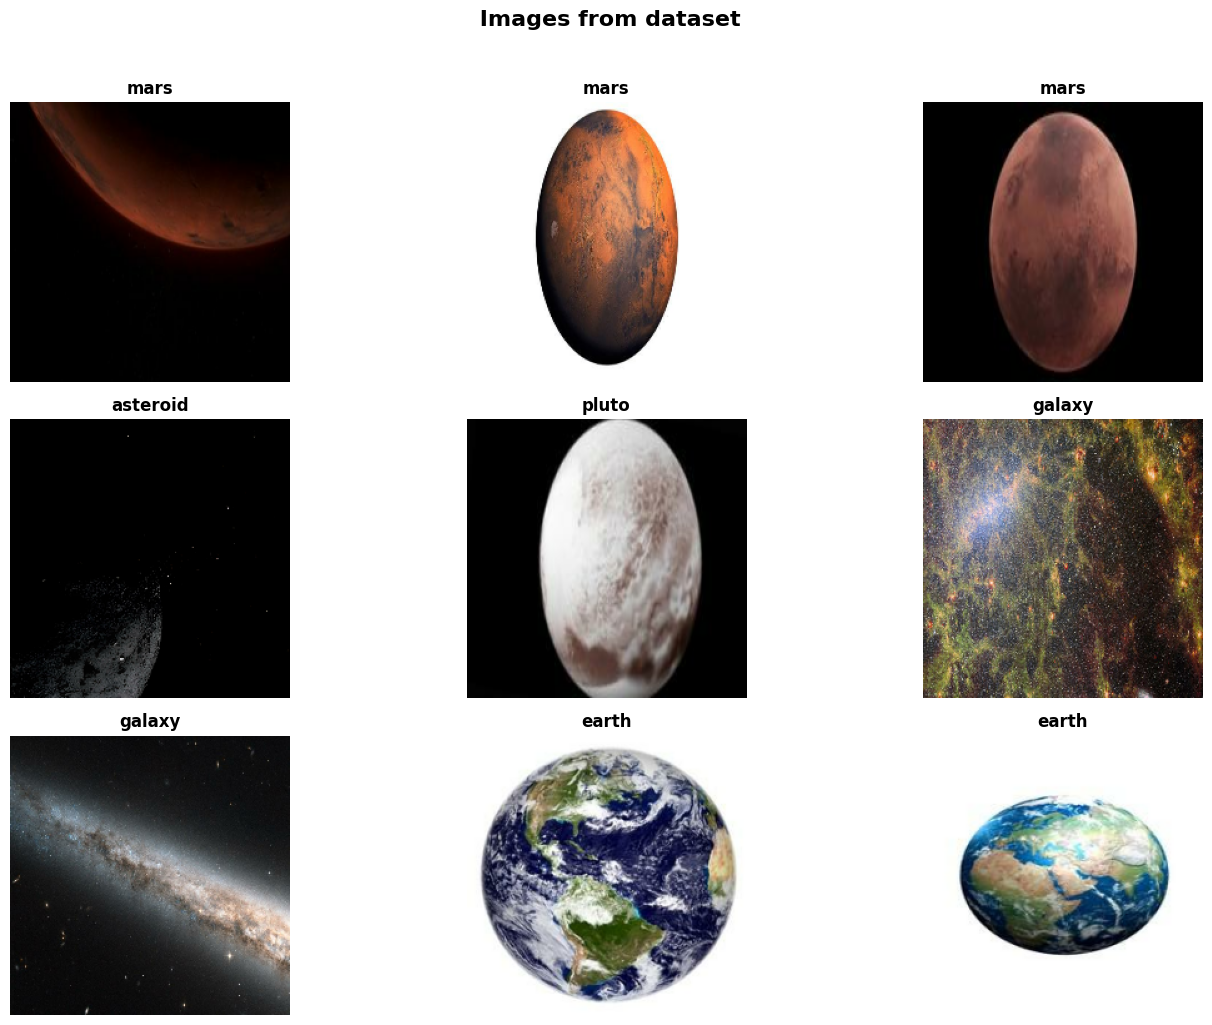

In [8]:

plt.figure(figsize=(15, 10))
for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]], fontsize=12, fontweight='bold')
        plt.axis("off")
plt.suptitle(' Images from dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Build CNN Model

In [9]:

model = Sequential([
    Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(224, 224, 3)),
    Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    
    Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    
    Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(class_names), activation='softmax')
], name='astro_classifier')

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "astro_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,187,244 (42.68 MB)

 Trainable params: 11,187,244 (42.68 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile Model

In [10]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Step 7: Train Model

In [11]:

print("Starting training...")
history = model.fit(
    train_dataset,
    epochs=10,
    verbose=1
)

Starting training...
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.3435 - loss: 1.9164
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.7721 - loss: 0.6919
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.8562 - loss: 0.4274
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.9268 - loss: 0.2392
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.9405 - loss: 0.1625
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.9541 - loss: 0.1412
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9503 - loss: 0.1612
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.9720 - loss: 0.0964
Epoch 9/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.9697 - loss: 0.1219
Epoch 10/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9836 - loss: 0.0593


## Step 8: Visualize Training Results

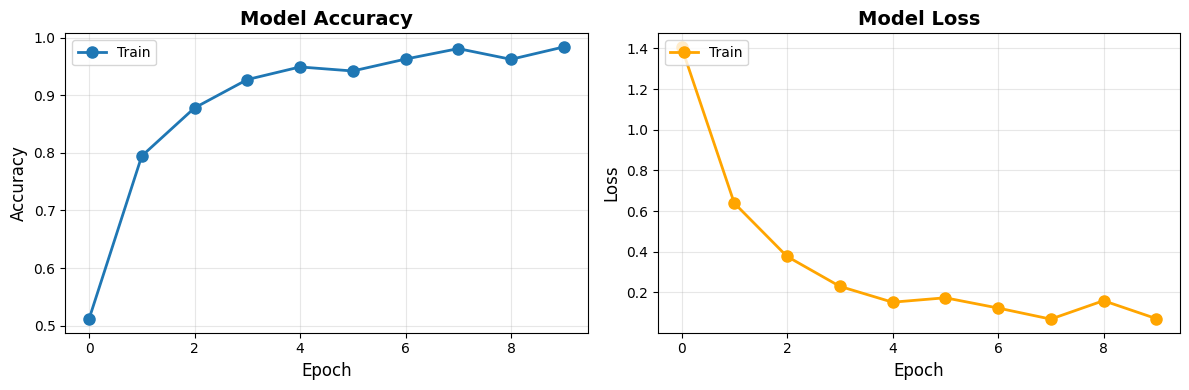

In [12]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', linewidth=2, markersize=8)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['Train'], loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', color='orange', linewidth=2, markersize=8)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['Train'], loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:

final_accuracy = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]

print(f"Training Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"Training Loss: {final_loss:.4f}")


Training Accuracy: 0.9843 (98.43%)
Training Loss: 0.0711


## Step 9: Save Model

In [14]:

model.save('astro_classifier_model.keras')
print("\n Model saved successfully as 'astro_classifier_model.keras'")


 Model saved successfully as 'astro_classifier_model.keras'


## Step 10: Test Predictions

In [15]:

print("Sample Predictions:\n")
for images, labels in train_dataset.take(1):
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    
    for i in range(min(5, len(images))):
        true_label = class_names[labels[i]]
        pred_label = class_names[predicted_classes[i]]
        confidence = predictions[i][predicted_classes[i]]
        
        print(f" True: {true_label:20s} | Predicted: {pred_label:20s} | Confidence: {confidence:.2%}")

Sample Predictions:

 True: earth                | Predicted: earth                | Confidence: 99.97%
 True: pluto                | Predicted: pluto                | Confidence: 90.94%
 True: uranus               | Predicted: uranus               | Confidence: 99.98%
 True: jupiter              | Predicted: jupiter              | Confidence: 99.86%
 True: venus                | Predicted: venus                | Confidence: 100.00%
